In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# # ON SERVER
# RESULTS_DIR = "/n/holylfs06/LABS/kempner_fellow_wcarvalho"
# USER_RESULTS_DIR = os.path.join(
#   RESULTS_DIR, "results/human_dyna_craftax/user_data/exps"
# )

In [13]:
# ON COMPUTER
RESULTS_DIR ='/Users/wilka/git/research/'
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, 'results/human_dyna_craftax/user_data/exps')

In [5]:
# from analysis.craftax_download_data import download_user_files
# import craftax_experiment_configs as config

# bucket_name = config.BUCKET_NAME  # google cloud
# bucket_prefix = "data/"
# # pattern = "data/data_user=*_name=r0-v2*debug=0.json"
# human_data_pattern = "data/*v1*debug=0.json"
# # human_data_pattern = "data/*4220*.json"


# download_user_files(
#     bucket_name=bucket_name,
#     prefix=bucket_prefix,
#     pattern=human_data_pattern,
#     destination_folder=USER_RESULTS_DIR)

In [5]:
import jax
import craftax_experiment_structure as experiment
from analysis import craftax_user_data
import nicewebrl
from analysis import craftax_analysis
import craftax_utils

example_timestep = experiment.jax_web_env.reset(
  jax.random.PRNGKey(0), experiment.dummy_params
)

EnvParams(max_timesteps=300, day_length=100000, always_diamond=False, mob_despawn_distance=100000, max_attribute=5, god_mode=False, world_seeds=(3,), current_goal=0, start_positions=Array([[28, 25],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0]], dtype=int32), goal_locations=((39, 44), (35, 13), (39, 46)), placed_goals=array([21, 22, 10]), fractal_noise_angles=(None, None, None, None), active_goals=Array([1., 1., 1.], dtype=float32), num_success=5, min_samples_per_location=2, num_start_locations=1)
[28 25] [28 25] [(28, 25)]


A* Iterations: 0it [00:00, ?it/s]

EnvParams(max_timesteps=300, day_length=100000, always_diamond=False, mob_despawn_distance=100000, max_attribute=5, god_mode=False, world_seeds=(15,), current_goal=0, start_positions=Array([[24, 24],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0]], dtype=int32), goal_locations=((40, 44), (37, 13), (38, 46)), placed_goals=array([22, 10, 21]), fractal_noise_angles=(None, None, None, None), active_goals=Array([1., 1., 1.], dtype=float32), num_success=5, min_samples_per_location=2, num_start_locations=1)
[24 24] [24 24] [(24, 24)]


A* Iterations: 0it [00:00, ?it/s]

EnvParams(max_timesteps=300, day_length=100000, always_diamond=False, mob_despawn_distance=100000, max_attribute=5, god_mode=False, world_seeds=(20,), current_goal=0, start_positions=Array([[18, 30],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0]], dtype=int32), goal_locations=((42, 30), (13, 13), (40, 32)), placed_goals=array([10, 21, 22]), fractal_noise_angles=(None, None, None, None), active_goals=Array([1., 1., 1.], dtype=float32), num_success=5, min_samples_per_location=2, num_start_locations=1)
[18 30] [18 30] [(18, 30)]


A* Iterations: 0it [00:00, ?it/s]

EnvParams(max_timesteps=300, day_length=100000, always_diamond=False, mob_despawn_distance=100000, max_attribute=5, god_mode=False, world_seeds=(95,), current_goal=0, start_positions=Array([[ 7, 16],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0],
       [ 0,  0]], dtype=int32), goal_locations=((3, 36), (17, 13), (6, 34)), placed_goals=array([21, 22, 10]), fractal_noise_angles=(None, None, None, None), active_goals=Array([1., 1., 1.], dtype=float32), num_success=5, min_samples_per_location=2, num_start_locations=1)
[ 7 16] [ 7 16] [(7, 16)]


A* Iterations: 0it [00:00, ?it/s]

# Get files

In [10]:
craftax_analysis.OPTIMAL_TEST_LENGTHS

{'world=3': 35, 'world=15': 39, 'world=20': 33, 'world=95': 28}

In [37]:
async def feedback(file):
    try:
        data = await nicewebrl.read_all_records(file)
    except Exception as e:
        print("-" * 25)
        print(os.path.basename(file))
        print(e)
        return
    if len(data) < 2:
        print(f"{file} has len{len(data)}")
    else:
        for idx in (1,2):
            finished = data[-idx].get("finished", False)
            if finished:
                print(idx, os.path.basename(file))
                print(data[-1]["feedback"] or "N/A")
        #         # print('bonus:', data[-1]['bonus'])
        #         # print("feedback:")
        # if "feedback" in data[-2]["data"]:
        #   pprint(data[-2]["data"])


In [24]:
from glob import glob
from pprint import pprint

files = f"{USER_RESULTS_DIR}/*2951292398*.json"
valid_files = list(set(list(glob(files))))

pprint(valid_files)

file = valid_files[0]
await feedback(file)

['/Users/wilka/git/research/results/human_dyna_craftax/user_data/exps/user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0.json']
1 user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0.json
N/A


Loaded episode data from /Users/wilka/git/research/results/human_dyna_craftax/user_data/exps//user=2951292398_worker=ASUYD8BPYM85M_name=craftax_v3-paths-r0-m0_debug=0_episode_data.bytes


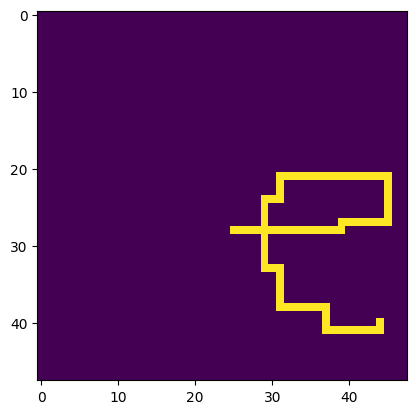

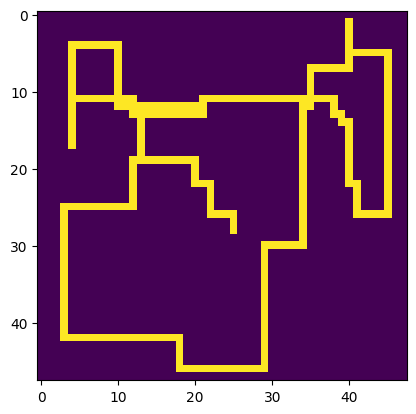

30


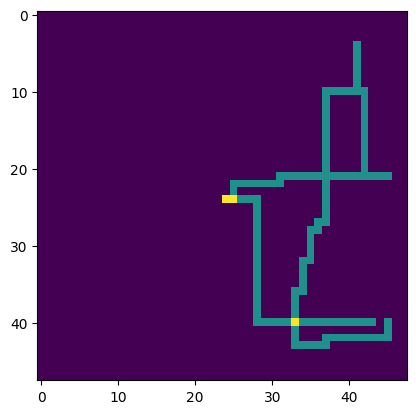

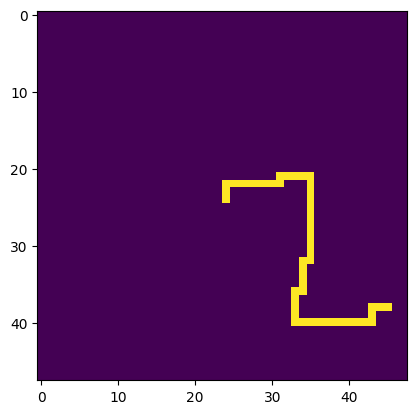

30
No training episodes for ('paths_2_training', 'paths_2_eval1')


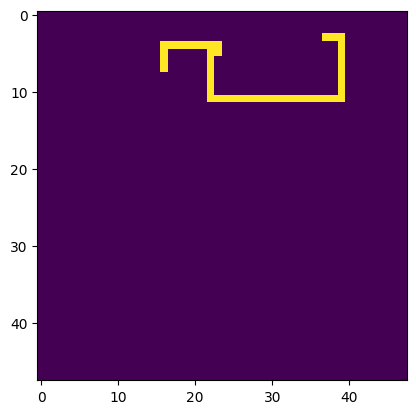

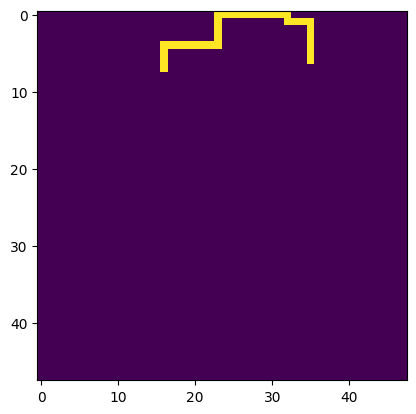

30


In [40]:
# %debug
file, episode_df, episode_data = await craftax_user_data.make_episode_data(
  file=file,
  example_timestep=example_timestep,
  debug=False,
  overwrite_episode_data=False,
  overwrite_episode_info=True,
)
if episode_df is not None and episode_data is not None:
  df = nicewebrl.DataFrame(episode_df, episode_data)



In [35]:
# craftax_utils.create_episode_reaction_times_video(df.filter(eval=False, name='paths_3_training').episodes[0])

,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
0,0,3,1,paths_0_eval1,reusing longer of two paths which matches training path,paths,18,1,True,10,0,[28 25],2951292398,36,Male,craftax_v3-paths-r0-m0,0,0,0,3,35,True,0.0,300,1.0,0.478102,-1.456733,-437.019775,-1.463204,0.478102,-0.079032,-0.23571,-0.460434,-0.079032,265,0,0.133333


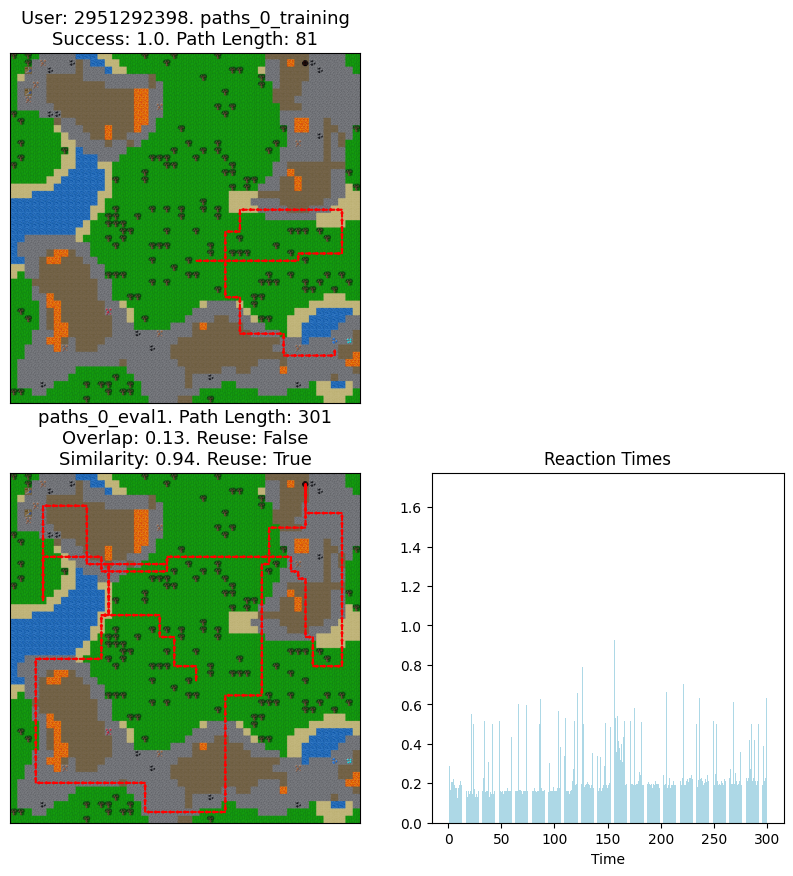

,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
0,0,15,1,paths_1_eval1,reusing longer of two paths which matches training path,paths,70,1,True,21,0,[24 24],2951292398,36,Male,craftax_v3-paths-r0-m0,0,0,0,3,39,False,1.0,50,1.0,0.251544,-1.468652,-73.43261,-1.503758,0.251544,-0.301092,-0.663569,-0.301092,-0.301092,11,1,0.366667


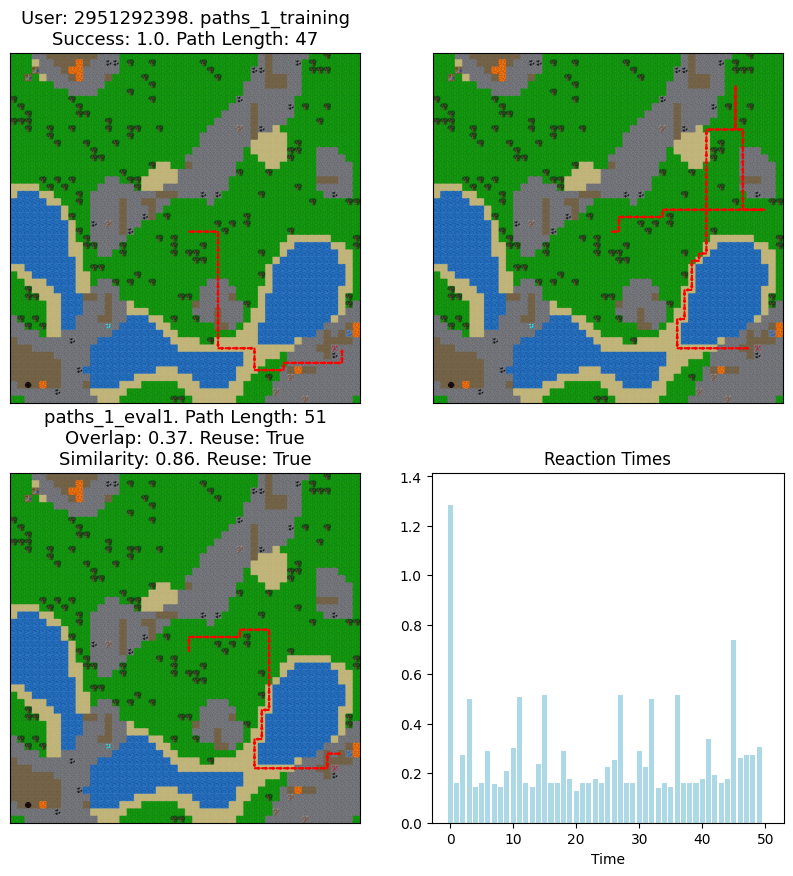

No train episodes for maze: paths_2_training


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
0,0,95,1,paths_3_eval1,reusing longer of two paths which matches training path,paths,36,1,True,10,0,[ 7 16],2951292398,36,Male,craftax_v3-paths-r0-m0,0,0,0,3,28,False,1.0,35,1.0,-0.100915,-1.471479,-51.501762,-1.51179,-0.100915,-0.454115,-0.454115,-0.689135,-0.689135,7,0,0.066667


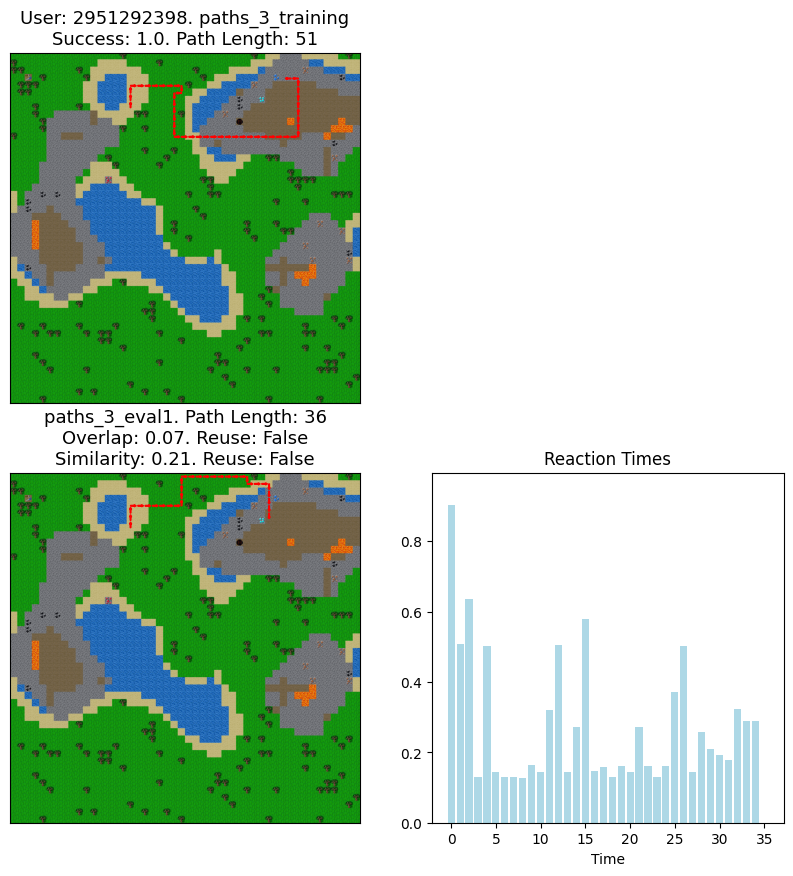

In [42]:
craftax_analysis.visualize_user_path_reuse(df, user_id=df['user_id'][0])

### 

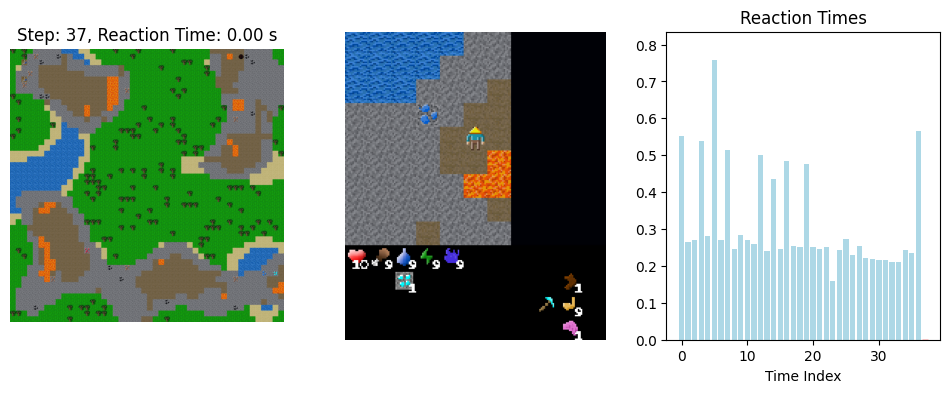

In [57]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(df.filter(eval=True, reuse=True).episodes[0])

In [59]:
df.filter(eval=True, reuse=False)['start_pos']

start_pos
str
"""[18 30]"""


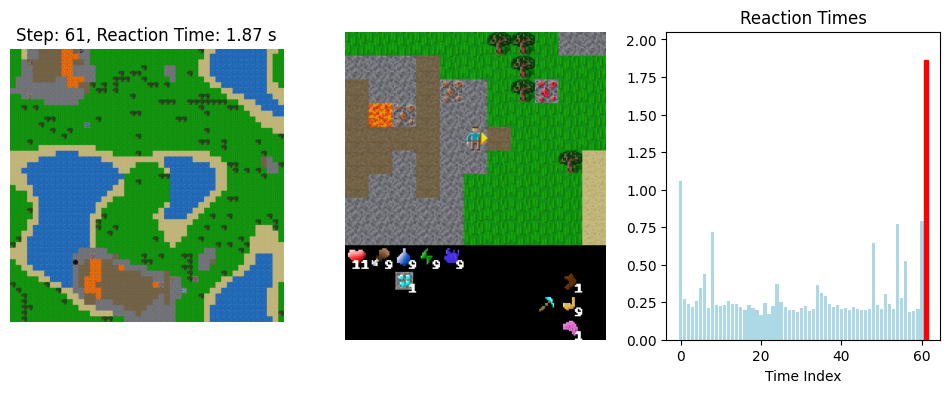

In [60]:
craftax_utils.create_episode_reaction_times_video(df.filter(eval=False, start_pos="[18 30]").episodes[0])

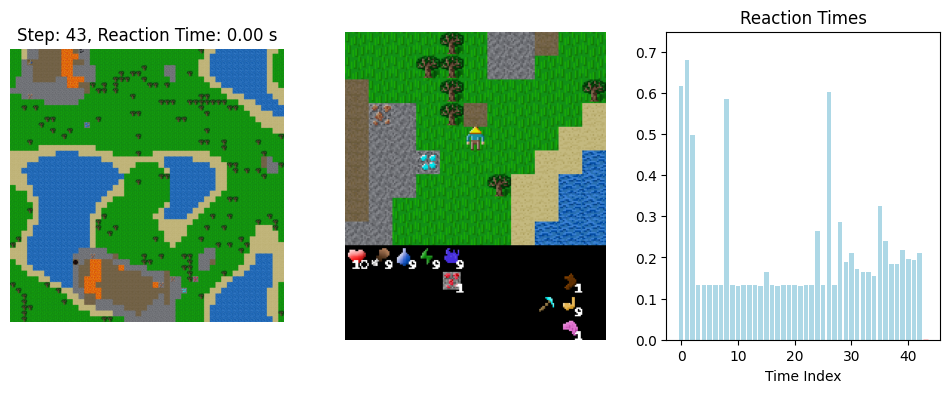

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(df.filter(eval=True, reuse=False).episodes[0])

In [33]:
all_mazes = df["name"].unique()
train_mazes = sorted([m for m in all_mazes if "training" in m])
test_mazes = sorted([m for m in all_mazes if "eval" in m])

# for i in range(len(train_mazes)):
name = test_mazes[0]
name = 'paths_3_eval1'
test = df.filter(name=name, eval=True)
start_pos = test["start_pos"].to_list()[0]

name = 'paths_3_training'
train = df.filter(
  name=name, room=0, eval=False, start_pos=start_pos
)
print(len(train.episodes))
test.head()

1


index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,bool,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,i32,f64
0,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",36,1,true,10,0,"""[ 7 16]""",2951292398,36,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,28,false,1.0,35,1.0,-0.100915,-1.471479,-51.501762,-1.51179,-0.100915,-0.454115,-0.454115,-0.689135,-0.689135,7,1,0.366667


In [35]:
train = df.filter(name=name, eval=False, start_pos=start_pos)
train.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,i64,bool,f64
0,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",0,1,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,32,1.0,0.36326,31,null,null
1,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",9,10,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,16,1.0,1.911911,15,null,null
2,95,0,"""paths_3_training""","""reusing longer of two paths wh…","""paths""",11,12,false,22,1,"""[ 7 16]""",2635592883,39,"""Male""","""craftax_v3-paths-r0-m0""",0,0,0,3,1,1.0,14,1.0,1.250191,13,null,null


In [68]:
df_added = craftax_user_data.add_reuse_columns(df, overlap_threshold=0.15)

In [69]:
not_reuse = df_added.filter(reuse=False)
not_reuse.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64


In [70]:
reused = df_added.filter(reuse=True)
reused.head()

index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap
u32,i64,i64,str,str,str,i64,i64,bool,i64,i64,str,i64,i64,str,str,i64,i64,i64,i64,i64,f32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,bool,f64
0,15,1,"""paths_1_eval1""","""reusing longer of two paths wh…","""paths""",17,1,true,21,0,"""[24 24]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,53,1.0,0.708533,-1.23248,-65.321426,-1.269807,0.708533,-0.006008,-0.006008,-0.970193,-0.648155,52,true,0.244898
1,20,1,"""paths_2_eval1""","""reusing longer of two paths wh…","""paths""",34,1,true,22,0,"""[18 30]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,45,1.0,0.359079,-1.486778,-66.905022,-1.52873,0.359079,-0.49921,-0.49921,-0.731867,-0.731867,44,true,0.622222
2,3,1,"""paths_0_eval1""","""reusing longer of two paths wh…","""paths""",51,1,true,10,0,"""[28 25]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,38,1.0,0.05355,-1.516469,-57.625835,-1.558902,0.05355,-0.848609,-0.848609,-0.928844,-0.928844,37,true,0.529412
3,95,1,"""paths_3_eval1""","""reusing longer of two paths wh…","""paths""",68,1,true,10,0,"""[ 7 16]""",4172656471,35,"""Female""","""craftax_v1-paths-r0-m1""",0,1,0,1,1,1.0,42,1.0,-1.093595,-1.606121,-67.4571,-1.618622,-0.918769,-0.918769,-1.15833,-0.918769,-0.918769,41,true,0.342105


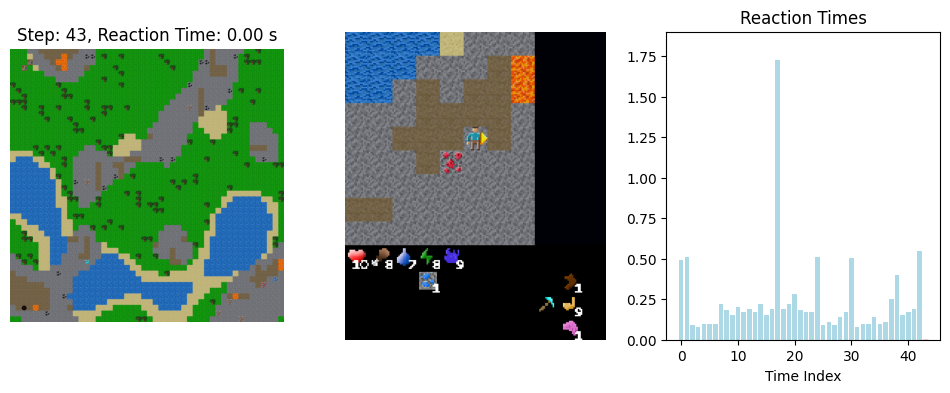

In [58]:
import craftax_utils

craftax_utils.create_episode_reaction_times_video(reused.episodes[0])

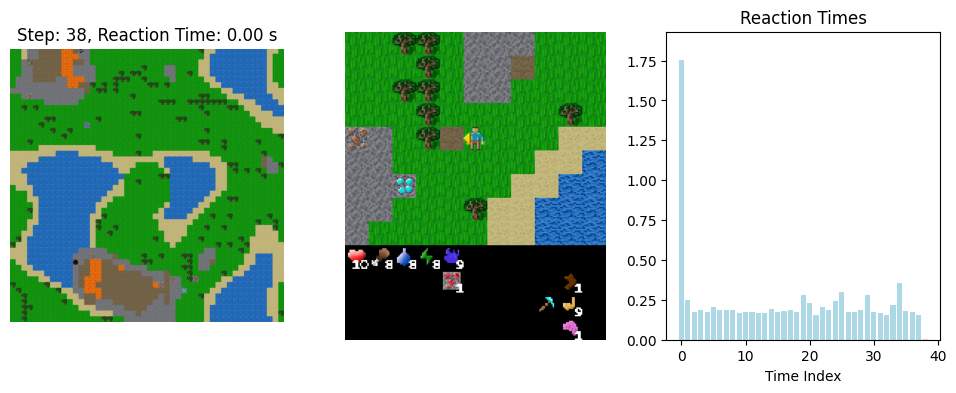

In [59]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[0])

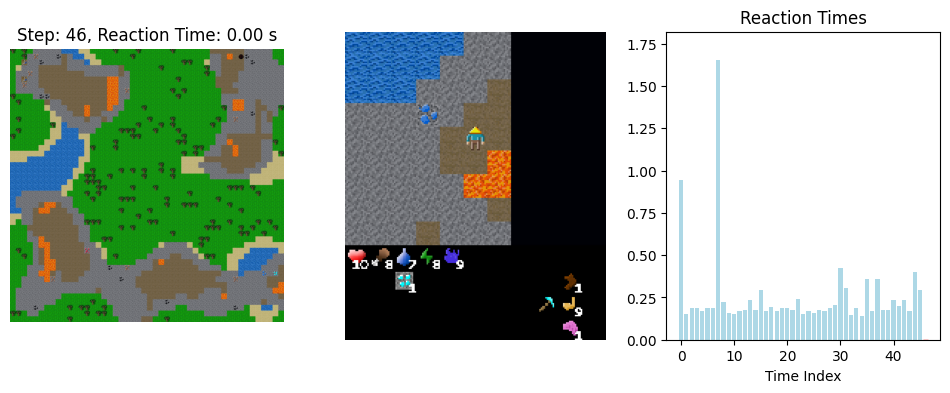

In [60]:
craftax_utils.create_episode_reaction_times_video(not_reuse.episodes[1])